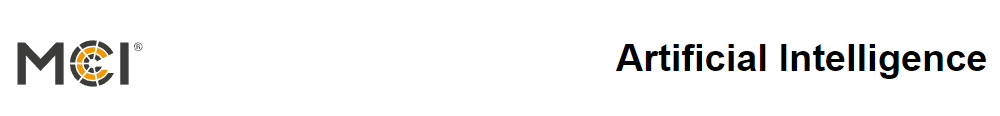

---

# 01 a YOLO Pose Estimation

First: Import all needed packages

https://docs.ultralytics.com/quickstart/#install-ultralytics

https://docs.ultralytics.com/quickstart/#use-ultralytics-with-python

In [25]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

## Keypoint Extraction

The next task we want to perform is a *Keypoint Extraction*. Therefore we need to define
 * the path to source picture
 * the YOLO model we want to use

In [26]:
# Path to the source image
picpath = "..\Data\Test_Images\Scene_1.jpg"
#picpath = "..\Data\Test_Images\Scene_2.jpg"
#picpath = "..\Data\Test_Images\Scene_3.jpg"
#picpath = "..\Data\Test_Images\Parkinsons_Pose.jpg"

# Load custom trained YOLOv8 model
# different models n, s, m, l, x
model_pose = YOLO('yolov8n-pose.pt')    # Pose Estimation

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\BNHOLLAUS\AppData\Local\Temp\ipykernel_21560\864087985.py:2: SyntaxWarning: invalid escape sequence '\D'
  picpath = "..\Data\Test_Images\Scene_1.jpg"


Now we can apply this model to our source image

In [27]:
results_pose = model_pose(picpath)  # predict on an image

image 1/1 c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\..\Data\Test_Images\Scene_1.jpg: 384x640 4 persons, 21.6ms
Speed: 1.3ms preprocess, 21.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


The output of the model tells us:
 * How many objects of each class
 * Processing time (preprocess, inference, postprocess)
 * Shape of the image

Now we can further analyse the results:

In [28]:
results_pose

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[ 39,  33,  26],
         [ 39,  33,  26],
         [ 39,  33,  26],
         ...,
         [136, 111,  91],
         [136, 112,  90],
         [136, 112,  90]],
 
        [[ 40,  34,  27],
         [ 39,  33,  26],
         [ 39,  33,  26],
         ...,
         [136, 111,  91],
         [136, 112,  90],
         [136, 112,  90]],
 
        [[ 40,  34,  27],
         [ 40,  34,  27],
         [ 40,  34,  27],
         ...,
         [136, 111,  91],
         [136, 112,  90],
         [136, 112,  90]],
 
        ...,
 
        [[117, 123, 130],
         [118, 124, 131],
         [118, 124, 131],
         ...,
         [143, 159, 171],
         [143, 159, 171],
         [144, 160, 172]],
 
        [[117, 123, 130],
         [117, 123, 130],
         [118, 124,

As with detection, the model returns an Ultralytics object. Basically, the results look identical. The only difference is that *names* only includes *Person* (so only persons are analyzed) and *keypoints* is no longer None. We will therefore take a closer look at this new *keypoints* object

In [29]:
len(results_pose[0].keypoints)

4

In [30]:
results_pose[0].keypoints

ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.3604, 0.3874, 0.0343, 0.9543, 0.3018, 0.9980, 0.9817, 0.9940, 0.8831, 0.9698, 0.8127, 0.9991, 0.9977, 0.9971, 0.9936, 0.9674, 0.9531],
        [0.9744, 0.9330, 0.9110, 0.7986, 0.6769, 0.9961, 0.9953, 0.9851, 0.9795, 0.9727, 0.9660, 0.9988, 0.9986, 0.9973, 0.9972, 0.9880, 0.9881],
        [0.0220, 0.0109, 0.0096, 0.2288, 0.2197, 0.8076, 0.7329, 0.5780, 0.4612, 0.3146, 0.2453, 0.7926, 0.7608, 0.3093, 0.2776, 0.1040, 0.0962],
        [0.8487, 0.8619, 0.5256, 0.8614, 0.2392, 0.9749, 0.9245, 0.9020, 0.5376, 0.8004, 0.4643, 0.8545, 0.7608, 0.4987, 0.3197, 0.2059, 0.1295]])
data: tensor([[[9.7805e+02, 1.3499e+02, 3.6043e-01],
         [9.7830e+02, 1.1690e+02, 3.8741e-01],
         [9.8734e+02, 1.1700e+02, 3.4331e-02],
         [9.9278e+02, 1.0933e+02, 9.5426e-01],
         [1.0648e+03, 1.0250e+02, 3.0178e-01],
         [9.9173e+02, 1.9355e+02, 9.9795e-01],
         [1.1494e+03, 1.7778e+02, 9.8173e-01],
         [9.

What we can see:
* Four persons were detected
* conf: Confidence of the keypoint of each person
* xy (xyn): Position of each keypoint
* data: xy position + the confidence

Hint: If you can't see xy, xyn, etc. make the output scrollable an have a look at the rest of the output (as it is most liekly truncated)

Now we want to visualize the results. Therefore the first step is to save the image to a file. The easiest way is to set the inference argument *save* True. Therefore the resulting picture including the boxes will be saved under 'runs\detect\predict'

In [31]:
results_det = model_pose(source=picpath, save=True)


image 1/1 c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\..\Data\Test_Images\Scene_1.jpg: 384x640 4 persons, 27.8ms
Speed: 1.0ms preprocess, 27.8ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\runs\pose\predict3


We can now navigate to the saved file via explorer and open it.

The next task is to visualize the results directly in the notebook. There are different packages and ways of doing this. One package which is easy to use is the Pillow package. We import *Image* from PIL and use it to generate a picture from the results array (plot function: https://docs.ultralytics.com/modes/predict/#working-with-results)

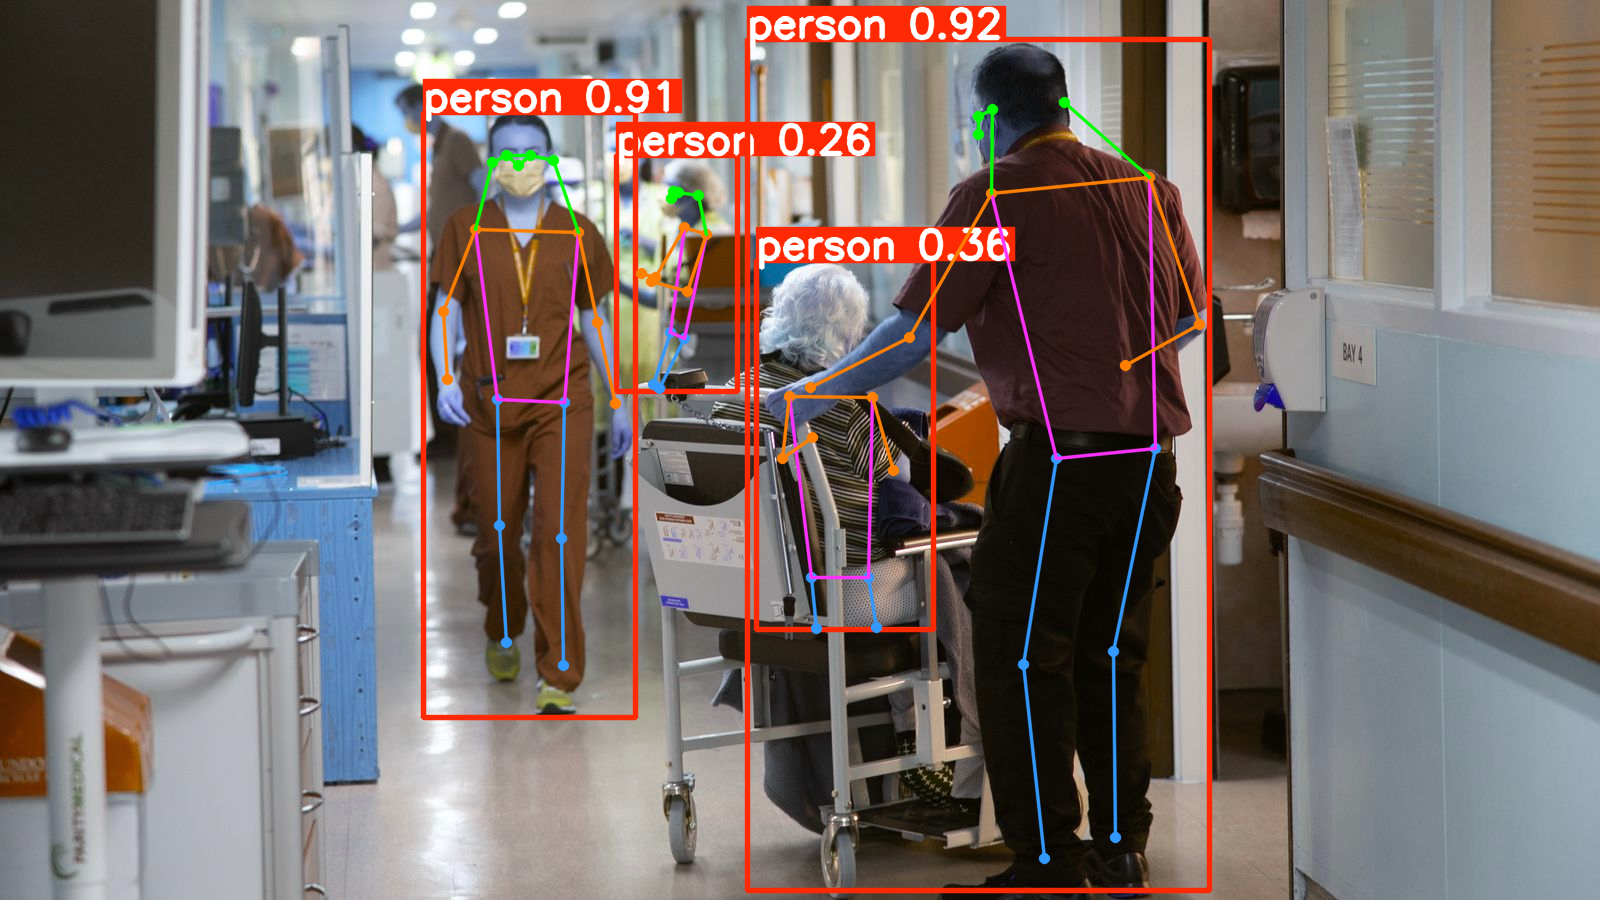

In [32]:
im_array = results_det[0].plot()
Image.fromarray(im_array)


#im_array_org = results[0].orig_img
#Image.fromarray(im_array_org[..., ::-1 ])

To solve this RGB BGR Problem, multiple approaches can be used:  https://docs.ultralytics.com/reference/engine/results/#ultralytics.engine.results.Results.plot

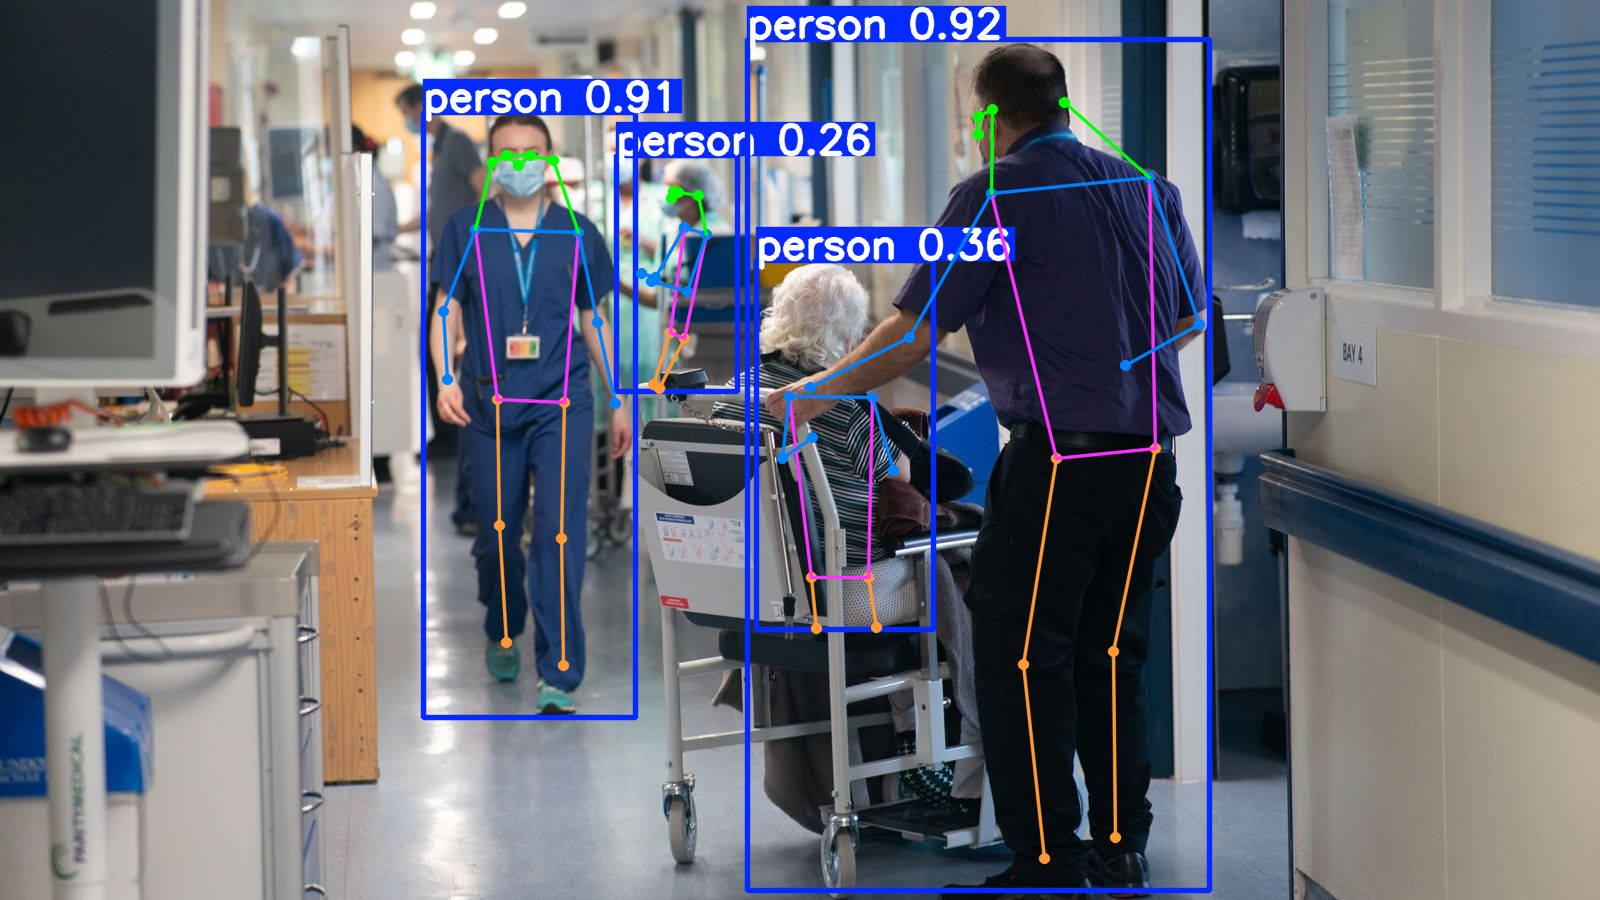

In [33]:
im_array = results_det[0].plot()
Image.fromarray(im_array[..., ::-1 ])

#### TASK:
Now we play around a little bit. Try the following things:
* Use a different size of the model (s,m,l) --> What can you see?
* Use a picture of your choise
* Think about how you could apply this to specific problems in medicine, rehabilitation and sports

Possible applications could be:
* https://doi.org/10.1371/journal.pone.0344375
* https://doi.org/10.1088/1361-6501/ae2a5d
* https://pubmed.ncbi.nlm.nih.gov/40270413/



